In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from utils import performance_dict

In [3]:
df = pd.read_csv('/home/server/Projects/data/AKI/aki_data.csv')

In [4]:
col_to_move = "aki"
df = df[[col for col in df.columns if col != col_to_move] + [col_to_move]]

In [5]:
df["aki_boolean"] = (df["aki"] > 0.3)

In [6]:
df["aki_positive"] = df["aki"].clip(lower=0)

In [7]:
df.select_dtypes(include='bool').columns

Index(['aki_boolean'], dtype='object')

In [8]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [9]:
df.fillna(0, inplace=True)

In [10]:
y = df.iloc[:, -3].values
y_binary = df.iloc[:, -2].values
y_positive = df.iloc[:, -1].values
X = df.iloc[:, :-3].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
_, _, y_binary_train, y_binary_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)
_, _, y_positive_train, y_positive_test = train_test_split(X, y_positive, test_size=0.2, random_state=42)

In [ ]:
# np.savez_compressed("/home/server/Projects/data/AKI/preop_trainable/unfiltered.npz", X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, y_binary_train=y_binary_train, y_binary_test=y_binary_test, y_positive_train=y_positive_train, y_positive_test=y_positive_test)

In [ ]:
with np.load('/home/server/Projects/data/AKI/preop_trainable/unfiltered_andrew.npz', allow_pickle=True) as data:
    X_train=data["X_train"]
    X_test=data["X_test"]
    y_train=data["y_train"]
    y_test=data["y_test"]
    y_binary_train=data["y_binary_train"]
    y_binary_test=data["y_binary_test"]
    y_positive_train=data["y_positive_train"]
    y_positive_test=data["y_positive_test"]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
X_train

array([[29462.0, 29462.0, 60.0, ..., False, False, False],
       [45796.0, 45796.0, 50.0, ..., False, False, False],
       [39871.0, 39871.0, 75.0, ..., False, False, False],
       ...,
       [15411.0, 15411.0, 40.0, ..., False, False, False],
       [17554.0, 17554.0, 40.0, ..., False, False, False],
       [2940.0, 2940.0, 70.0, ..., False, False, False]], dtype=object)

In [ ]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_binary_train)

/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10000)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
performance_dict(y_binary_test, y_pred, y_prob)

{'Precision': 0.19646719538572457,
 'Sensitivity': 0.7808022922636103,
 'Accuracy': 0.7967403362061609,
 'rc_auc': 0.8614924776325685,
 'pr_auc': 0.2658558068983938,
 'Specificity': 0.7977497504763633,
 'Negative Precision': 0.9828954723309111,
 'F1 Score': 0.31394009216589863}

In [ ]:
accuracy = accuracy_score(y_binary_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.80


In [ ]:
cm = confusion_matrix(y_binary_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[8827 2194]
 [ 152  546]]


In [ ]:
report = classification_report(y_binary_test, y_pred)
print('Classification Report:')
print(report)

Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.80      0.88     11021
        True       0.20      0.78      0.32       698

    accuracy                           0.80     11719
   macro avg       0.59      0.79      0.60     11719
weighted avg       0.94      0.80      0.85     11719



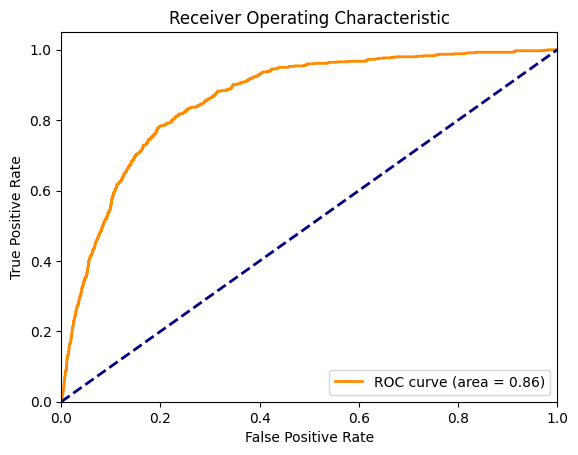

In [ ]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

Mean Absolute Error: 0.30539811917489035
Mean Squared Error: 0.18964211330359718
Root Mean Squared Error: 0.43547917665899616
R-squared: -1.157627964321812


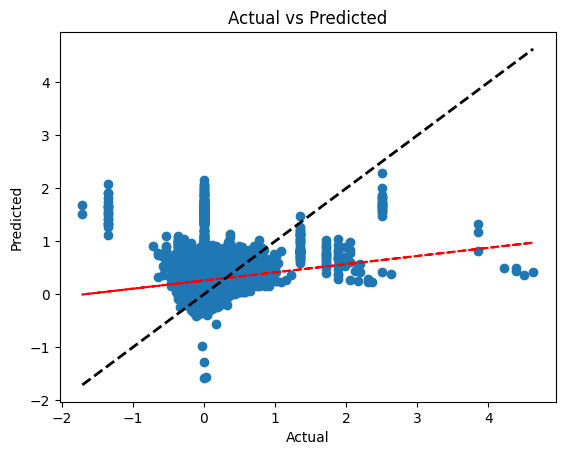

In [ ]:
# Plotting the actual vs predicted values
plt.scatter(y_test, y_pred)
z = np.polyfit(y_test, y_pred, 1)  # 1 indicates a linear fit
p = np.poly1d(z)
# Plot the trendline
plt.plot(y_test, p(y_test), color='red', linestyle='--', label='Trendline')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
y_pred_binary = y_pred > 0.3

accuracy = accuracy_score(y_binary_test, y_pred_binary)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_binary_test, y_pred_binary)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_binary_test, y_pred_binary)
print('Classification Report:')
print(report)

Accuracy: 0.67
Confusion Matrix:
[[6393 3203]
 [ 221  438]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.67      0.79      9596
        True       0.12      0.66      0.20       659

    accuracy                           0.67     10255
   macro avg       0.54      0.67      0.50     10255
weighted avg       0.91      0.67      0.75     10255



In [ ]:
model.coef_

array([-3.06963002e-04,  2.24436964e-02,  1.03629016e-03,  3.88609060e-03,
        4.53558050e-02, -1.21392670e-02, -3.04729035e-01,  9.21441350e-04,
       -5.09777663e-04,  1.81795415e-03, -1.23219462e+00,  2.17728952e-01,
        1.79702481e-02, -2.54772602e-03,  3.07680107e-02, -3.09790721e-04,
       -3.95592969e-04, -2.34116815e-03,  4.33827492e-04, -1.02939629e-02,
        1.54351366e-04, -4.92636067e-02, -5.26462042e-02,  1.20308115e-04,
        1.68753777e+00,  6.06492409e-02,  2.90197891e-02,  2.88835149e-04,
        1.24579150e-03, -1.60556716e-02, -5.74160581e-03, -2.98280880e-04,
       -2.01667997e-03, -3.02089110e-02,  3.03766554e-03, -1.04775313e-04,
        1.26456483e-03, -2.01262618e-14,  2.12330153e-15, -2.44273034e-01,
       -2.18983585e-01,  6.93889390e-16,  1.08246745e-15,  1.49189007e-01,
        1.49189007e-01,  7.18869408e-15,  3.77475828e-15,  5.27016152e-02,
        5.27016152e-02, -1.12502693e-02, -4.69578513e-01,  5.22633607e-01,
       -4.77301742e-03, -

In [ ]:
model.intercept_

1.6289258804041964

In [ ]:
from sklearn.utils import resample
# SMOTe
df_majority = df[df["aki_boolean"] == 0]
df_minority = df[df["aki_boolean"] == 1]

# Upsample minority class
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # Sample with replacement
                                 n_samples=len(df_majority),    # Match number in majority class
                                 random_state=42)  # Reproducible results

# Combine majority class with upsampled minority class
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [ ]:
df = pd.read_csv('/home/server/Projects/data/AKI/aki_data.csv')

col_to_move = "aki"
df = df[[col for col in df.columns if col != col_to_move] + [col_to_move]]
df["aki_boolean"] = (df["aki"] > 0.3)
df["aki_positive"] = df["aki"].clip(lower=0)
df["sex"] = df["sex"] == "M"
df = df[(df['weight'] != 0) & (df['height'] != 0)]
df.pop("postop_creatinine")
df.pop("Unnamed: 0")
df.pop("Unnamed: 0.1")
df.pop("Unnamed: 0.2")
df.pop("op_id")
df.pop("subject_id")
df.pop("opstart_time")
df.pop("opend_time")
df.pop("inhosp_death_time")
df.pop("allcause_death_time")

# missing data indicators
for col in df.columns:
    # Create a new column with a suffix '_isna' indicating NaN status
    df[f'{col}_isna'] = df[col].isna()
df.fillna(df.mean(), inplace=True)

# replace outliers w more reasonable values
np.random.seed(42)
int_columns = df.select_dtypes(include=['int']).columns
df[int_columns] = df[int_columns].astype(float)
ignore = ["sex", "asa", "emop", "num_card_events"]
for col in df.columns:
    if "isna" in col or "aki" in col or col in ignore:
        continue
    lower_1 = df[col].quantile(0.01)
    upper_1 = df[col].quantile(0.99)
    lower_05 = df[col].quantile(0.005)
    lower_5 = df[col].quantile(0.05)
    upper_95 = df[col].quantile(0.95)
    upper_995 = df[col].quantile(0.995)
    mask_lower = df[col] < lower_1
    mask_upper = df[col] > upper_1
    df.loc[mask_lower, col] = np.random.uniform(lower_05, lower_5, mask_lower.sum())
    df.loc[mask_upper, col] = np.random.uniform(upper_95, upper_995, mask_upper.sum())

In [ ]:
for col in df.columns:
    if "isna" in col or "aki" in col or col in ignore:
        continue
    print(col, df[col].min(), df[col].max())

age 20.0 85.0
height 140.0 184.9971767328613
weight 35.04632023004603 99.99120588656
BSA 1.2081350952494272 2.23556111122454
BMI 14.568195511713371 37.312159060712474
booking_case_length 55.019601722838985 769.4035880877032
last_preop_scr 0.41002724458619066 3.04
min_preop_scr 0.41 3.0379359202447693
preop_total_protein 4.6 7.9
preop_sodium 128.0 146.9974012018888
preop_potassium 3.0 5.0
preop_platelet 63.0 470.0
preop_glucose 78.0 263.9278642038531
preop_wbc 2.6301903937012563 19.43086519602406
preop_alt 6.0 126.0
preop_chloride 92.0035842935329 112.98320947111968
preop_lymphocyte 2.0027489392424718 47.8
preop_phosphorus 1.7034876639652643 4.8
preop_albumin 2.3000369788526074 4.7
preop_fibrinogen 148.0 606.0
preop_creatinine 0.41002890494214395 3.04
preop_ptinr 0.88 1.7588324752708813
preop_total_bilirubin 0.3 6.198431385162044
preop_alp 33.0 295.417931560753
preop_aptt 24.0 56.4
preop_calcium 7.300126195662445 10.0
preop_bun 6.0 49.966160527873456
preop_ast 11.0 108.0
preop_crp 0.01 

In [ ]:
df = pd.read_csv('/home/server/Projects/data/AKI/aki_data.csv')
col_to_move = "aki"
df = df[[col for col in df.columns if col != col_to_move] + [col_to_move]]
df["aki_boolean"] = (df["aki"] > 0.3)
df["aki_positive"] = df["aki"].clip(lower=0)
df["sex"] = df["sex"] == "M"
df = df[(df['weight'] != 0) & (df['height'] != 0)]
df.pop("postop_creatinine")
df.pop("Unnamed: 0")
df.pop("Unnamed: 0.1")
df.pop("Unnamed: 0.2")
df.pop("op_id")
df.pop("subject_id")
df.pop("opstart_time")
df.pop("opend_time")
df.pop("inhosp_death_time")
df.pop("allcause_death_time")

for col in df.columns:
    if "isna" in col or "aki" in col or col in ignore:
        continue
    print(col, df[col].min(), df[col].max())

age 20 90
height 5.0 1710.0
weight 10.0 180.0
BSA 0.2763853991962833 6.164414002968976
BMI 0.2586820151328979 22000.0
booking_case_length 15.0 5910.0
last_preop_scr 0.41 5.55
min_preop_scr 0.41 3.04
preop_total_protein 4.3 7.9
preop_sodium 128.0 147.0
preop_potassium 3.0 5.3
preop_platelet 44.0 470.0
preop_glucose 78.0 302.0
preop_wbc 2.63 19.44
preop_alt 6.0 209.0
preop_chloride 92.0 113.0
preop_lymphocyte 2.0 47.8
preop_phosphorus 1.7 5.3
preop_albumin 2.3 4.7
preop_fibrinogen 118.0 606.0
preop_creatinine 0.41 3.04
preop_ptinr 0.88 2.56
preop_total_bilirubin 0.3 6.2
preop_alp 33.0 296.0
preop_aptt 24.0 70.6
preop_calcium 7.3 10.0
preop_bun 6.0 64.0
preop_ast 11.0 180.0
preop_crp 0.01 22.26
preop_hb 7.6 15.6
preop_hct 22.0 46.0
preop_seg 38.8 92.0
op_len 0.0 2140.0


In [ ]:
df["preop_potas"]

KeyError: 'preop_pot'

In [ ]:
df = pd.read_csv("/home/server/Projects/data/AKI/preop_data_andrew.csv")
# we see that adding more antypes and department information sloghtly improves the model
# to understand this better we checked the aki positive rate for each antype, but we found
# that the aki positive rate is lower for the added antype values

#

In [ ]:
df["aki_boolean"] = (df["aki"] > 0.3)

In [ ]:
df[df['antype'] == 0]['aki_boolean'].value_counts()

aki_boolean
False    48070
True      3298
Name: count, dtype: int64

In [ ]:
df[df['antype'] == 1]['aki_boolean'].value_counts()

aki_boolean
False    7127
True      195
Name: count, dtype: int64

In [ ]:
195/(195+7127)

0.026632067741054356

In [ ]:
(3298)/(3298+48070)

0.06420339510979599

# LR Variant Testing

Tests no regularization, Ridge (L2), LASSO (L1), and ElasticNet

In [3]:
import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, precision_score, recall_score

# =============================================================================
# SCRIPT CONFIGURATION
# =============================================================================
TARGET = 'aki_boolean'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Dataset File Paths ---
# The script will loop through each of these datasets.
datasets_to_run = [
    {'name': 'preop', 'path': '/home/server/Projects/data/AKI/tabular_preop.csv'},
    {'name': 'intraop', 'path': '/home/server/Projects/data/AKI/tabular_intraop.csv'},
    {'name': 'combined', 'path': '/home/server/Projects/data/AKI/tabular_combined.csv'},
]

# --- MODIFIED: Dataset Test Toggles ---
# Set a dataset to False to skip its run.
dataset_configs = {
    'preop': False,
    'intraop': True,
    'combined': False,
}


# --- Logistic Regression Variant Configurations ---
# Solvers have been optimized for speed and tolerance relaxed for faster convergence.
lr_variants = [
    {'name': 'LR (L2 Regularization)', 'params': {'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1000, 'tol': 0.01}},
    {'name': 'LR (L1 Regularization)', 'params': {'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 1000, 'tol': 0.01}},
    {'name': 'LR (Elastic Net)', 'params': {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5, 'max_iter': 5000, 'tol': 0.01}},
    {'name': 'LR (No Regularization)', 'params': {'penalty': None, 'solver': 'lbfgs', 'max_iter': 1000, 'tol': 0.01}},
]

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def performance_dict(y_true, y_pred_binary, y_prob):
    """Calculates a dictionary of performance metrics."""
    # Ensure probabilities are valid for roc_auc_score
    if len(np.unique(y_true)) < 2:
        auc = 0.5 # Default AUC if only one class is present in y_true
    else:
        auc = roc_auc_score(y_true, y_prob)
        
    return {
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred_binary),
        'roc_auc': auc,
        'precision': precision_score(y_true, y_pred_binary, zero_division=0),
        'recall': recall_score(y_true, y_pred_binary, zero_division=0),
    }

def log_performance(variant_name, dataset_name, training_time, perf_dict):
    """Prints a formatted log of the results for a given run."""
    print("\n" + "="*70)
    print(f"RESULTS FOR: {variant_name} on {dataset_name.upper()} DATA")
    print(f"  - Training Time: {training_time:.4f} seconds")
    for metric, value in perf_dict.items():
        print(f"  - {metric:<20}: {value:.4f}")
    print("="*70 + "\n")

# =============================================================================
# MAIN EXPERIMENT LOOP
# =============================================================================
for dataset_info in datasets_to_run:
    dataset_name = dataset_info['name']
    
    # MODIFIED: Check if the current dataset should be run
    if not dataset_configs.get(dataset_name, False):
        print(f"\n{'#'*25} SKIPPING DATASET: {dataset_name.upper()} {'#'*25}\n")
        continue

    file_path = dataset_info['path']
    
    print(f"\n{'#'*25} PROCESSING DATASET: {dataset_name.upper()} {'#'*25}\n")

    # --- 1. Load Data ---
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"--> WARNING: Data file not found at: {file_path}. Skipping this dataset.")
        continue

    # --- 2. Prepare Data (Single Train/Test Split) ---
    feature_cols = [col for col in df.columns if col not in ['op_id', TARGET]]
    X = df[feature_cols].values
    y = df[TARGET].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    
    # Feature scaling is crucial for regularized models and the 'saga' solver
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- 3. Run Each LR Variant ---
    for variant in lr_variants:
        variant_name = variant['name']
        variant_params = variant['params']

        # Instantiate the model with the specified parameters
        model = LogisticRegression(**variant_params, class_weight='balanced', random_state=RANDOM_STATE)
        
        # Time the training process
        print(f"--> Training {variant_name}...")
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        end_time = time.time()
        training_time = end_time - start_time
        
        # Make predictions
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        
        # Calculate and log performance
        perf_metrics = performance_dict(y_test, y_pred, y_prob)
        log_performance(variant_name, dataset_name, training_time, perf_metrics)

print("\n\nLogistic Regression variant analysis finished.")



######################### SKIPPING DATASET: PREOP #########################


######################### PROCESSING DATASET: INTRAOP #########################

--> Training LR (L2 Regularization)...

RESULTS FOR: LR (L2 Regularization) on INTRAOP DATA
  - Training Time: 35.9454 seconds
  - balanced_accuracy   : 0.7631
  - roc_auc             : 0.8410
  - precision           : 0.1385
  - recall              : 0.7441

--> Training LR (L1 Regularization)...

RESULTS FOR: LR (L1 Regularization) on INTRAOP DATA
  - Training Time: 134.7639 seconds
  - balanced_accuracy   : 0.7599
  - roc_auc             : 0.8403
  - precision           : 0.1371
  - recall              : 0.7386

--> Training LR (Elastic Net)...

RESULTS FOR: LR (Elastic Net) on INTRAOP DATA
  - Training Time: 125.4705 seconds
  - balanced_accuracy   : 0.7606
  - roc_auc             : 0.8368
  - precision           : 0.1379
  - recall              : 0.7386

--> Training LR (No Regularization)...

RESULTS FOR: LR (No Regulariza

# HPO GridSearchCV

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import time
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score, # Already imported, will be used as scorer
    confusion_matrix,
    precision_recall_curve,
    auc,
    average_precision_score
)
# Removed StandardScaler import as it's not used

# --- Performance Dictionary (Comprehensive) ---
def performance_dict(y_true, y_pred, y_prob, model_name="Model", bool_print=True):
    if bool_print:
        print(f"\n--- Test Set Performance for Best {model_name} ---")

    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    precision_positive = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    sensitivity_recall_positive = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_positive = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob, pos_label=1)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    if bool_print:
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Balanced Accuracy: {balanced_acc:.4f}") # This is the HPO metric
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"PR AUC: {pr_auc:.4f}")
        print(f"Precision (Class 1): {precision_positive:.4f}")
        print(f"Sensitivity (Recall for Class 1): {sensitivity_recall_positive:.4f}")
        print(f"F1 Score (Class 1): {f1_positive:.4f}")
        print(f"Specificity (TNR for Class 0): {specificity:.4f}")
        print(f"Negative Predictive Value (NPV for Class 0): {npv:.4f}")

    return {
        "Model Name": model_name,
        "Test Accuracy": accuracy,
        "Test Balanced Accuracy": balanced_acc, # This is the HPO metric
        "Test ROC AUC": roc_auc,
        "Test PR AUC": pr_auc,
        "Test Precision (C1)": precision_positive,
        "Test Sensitivity (C1)": sensitivity_recall_positive,
        "Test F1 (C1)": f1_positive,
        "Test Specificity (C0)": specificity,
        "Test NPV (C0)": npv,
    }

# --- Data Loading and Preparation ---
file = "/home/server/Projects/data/AKI/tabular_combined.npz" # Replace with your actual file path
feature_names = []

try:
    with np.load(file, allow_pickle=True) as data:
        X_train = data["X_train"] # Using data directly as it's pre-normalized
        X_test = data["X_test"]   # Using data directly as it's pre-normalized
        y_binary_train = data["y_binary_train"].astype(int)
        y_binary_test = data["y_binary_test"].astype(int)
    print(f"Data loaded successfully from {file}.")
    print("Using pre-normalized data as input (StandardScaler step removed).")
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]
except FileNotFoundError:
    print(f"Warning: File {file} not found. Using dummy imbalanced data for demonstration.")
    n_features = 20
    n_samples = 5000
    X_dummy = np.random.rand(n_samples, n_features) # Dummy data is not pre-normalized here
                                                 # but for consistency, we'll skip scaling in the dummy path too
    y_binary = np.zeros(n_samples, dtype=int)
    positive_indices = np.random.choice(n_samples, size=int(0.05 * n_samples), replace=False)
    y_binary[positive_indices] = 1
    X_train, X_test, y_binary_train, y_binary_test = train_test_split(
        X_dummy, y_binary, test_size=0.25, stratify=y_binary, random_state=42
    )
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]
    print(f"Using dummy data: X_train shape {X_train.shape}, y_binary_train class distribution {np.bincount(y_binary_train)}")
    print("Note: Dummy data is not pre-normalized, but StandardScaler step is skipped to match user request.")


# --- Common Model Parameters ---
CLASS_WEIGHT_SETTING = 'balanced'
MAX_ITER_HPO = 5000
SAGA_TOL_HPO = 0.01
RANDOM_STATE = 42
CV_FOLDS = 3 # Increase for more robust HPO (e.g., 5)

print(f"Using class_weight setting: {CLASS_WEIGHT_SETTING}")
print(f"Max iterations for HPO models: {MAX_ITER_HPO}")
print(f"SAGA solver tolerance for HPO: {SAGA_TOL_HPO}")
print(f"CV folds for HPO: {CV_FOLDS}")

# --- Define Models and Parameter Grids for HPO ---
param_C = [0.001, 0.01, 0.1, 1, 10, 100]
param_l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9]

models_for_hpo = [
    {
        "name": "LR (Ridge L2)",
        "estimator": LogisticRegression(
            penalty='l2',
            solver='lbfgs',
            class_weight=CLASS_WEIGHT_SETTING,
            max_iter=MAX_ITER_HPO,
            random_state=RANDOM_STATE
        ),
        "param_grid": {'C': param_C}
    },
    {
        "name": "LR (LASSO L1)",
        "estimator": LogisticRegression(
            penalty='l1',
            solver='saga',
            class_weight=CLASS_WEIGHT_SETTING,
            max_iter=MAX_ITER_HPO,
            tol=SAGA_TOL_HPO,
            random_state=RANDOM_STATE
        ),
        "param_grid": {'C': param_C}
    },
    {
        "name": "LR (Elastic Net)",
        "estimator": LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            class_weight=CLASS_WEIGHT_SETTING,
            max_iter=MAX_ITER_HPO,
            tol=SAGA_TOL_HPO,
            random_state=RANDOM_STATE
        ),
        "param_grid": {'C': param_C, 'l1_ratio': param_l1_ratio}
    }
]

# --- HPO Loop ---
hpo_results_summary = []
best_estimators_after_hpo = {}

# Define scoring metric: Balanced Accuracy
scoring_metric = 'balanced_accuracy' # CHANGED
print(f"Using '{scoring_metric}' as the scoring metric for HPO.")

for model_spec in models_for_hpo:
    model_name = model_spec["name"]
    estimator = model_spec["estimator"]
    param_grid = model_spec["param_grid"]

    print(f"\n--- Starting HPO for {model_name} ---")
    
    strat_kfold = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring_metric, # CHANGED
        cv=strat_kfold,
        n_jobs=-1,
        verbose=1
    )

    hpo_start_time = time.time()
    grid_search.fit(X_train, y_binary_train) # Using X_train directly (pre-normalized)
    hpo_end_time = time.time()
    hpo_duration = hpo_end_time - hpo_start_time

    print(f"HPO for {model_name} took: {hpo_duration:.2f} seconds.")
    print(f"Best Parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best CV Score ({scoring_metric}) for {model_name}: {grid_search.best_score_:.4f}")

    best_model = grid_search.best_estimator_
    best_estimators_after_hpo[model_name] = best_model
    
    y_pred_test = best_model.predict(X_test) # Using X_test directly (pre-normalized)
    y_prob_test = best_model.predict_proba(X_test)[:, 1]
    
    test_perf = performance_dict(y_binary_test, y_pred_test, y_prob_test, model_name=model_name, bool_print=True)
    
    hpo_results_summary.append({
        "Model": model_name,
        "Best Params": str(grid_search.best_params_), # str for better df display
        f"Best CV {scoring_metric}": grid_search.best_score_,
        "HPO Time (s)": hpo_duration,
        **test_perf
    })

# --- Final HPO Results Summary ---
print("\n\n--- Hyperparameter Optimization Summary ---")
if hpo_results_summary:
    summary_df = pd.DataFrame(hpo_results_summary)
    cols_order = ["Model", "Best Params", f"Best CV {scoring_metric}", "Test Balanced Accuracy", "Test PR AUC", "Test Sensitivity (C1)", "Test F1 (C1)", "HPO Time (s)"]
    present_cols = [col for col in cols_order if col in summary_df.columns]
    remaining_cols = [col for col in summary_df.columns if col not in present_cols]
    summary_df = summary_df[present_cols + remaining_cols]
    print(summary_df.to_string())
else:
    print("No HPO results to display.")

Data loaded successfully from /home/server/Projects/data/AKI/tabular_combined.npz.
Using pre-normalized data as input (StandardScaler step removed).
Using class_weight setting: balanced
Max iterations for HPO models: 5000
SAGA solver tolerance for HPO: 0.01
CV folds for HPO: 3
Using 'balanced_accuracy' as the scoring metric for HPO.

--- Starting HPO for LR (Ridge L2) ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits


KeyboardInterrupt: 

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler # Import StandardScaler
import time
import os
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    auc,
    average_precision_score
)

# --- Performance Dictionary (Comprehensive) ---
def performance_dict(y_true, y_pred, y_prob, model_name_full="Model", bool_print=True):
    if bool_print:
        print(f"\n--- Test Set Performance for {model_name_full} ---")

    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    precision_positive = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    sensitivity_recall_positive = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_positive = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob, pos_label=1)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    if bool_print:
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Balanced Accuracy: {balanced_acc:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"PR AUC: {pr_auc:.4f}")
        print(f"Precision (Class 1): {precision_positive:.4f}")
        print(f"Sensitivity (Recall for Class 1): {sensitivity_recall_positive:.4f}")
        print(f"F1 Score (Class 1): {f1_positive:.4f}")
        print(f"Specificity (TNR for Class 0): {specificity:.4f}")
        print(f"Negative Predictive Value (NPV for Class 0): {npv:.4f}")

    return {
        "Test Accuracy": accuracy,
        "Test Balanced Accuracy": balanced_acc,
        "Test ROC AUC": roc_auc,
        "Test PR AUC": pr_auc,
        "Test Precision (C1)": precision_positive,
        "Test Sensitivity (C1)": sensitivity_recall_positive,
        "Test F1 (C1)": f1_positive,
        "Test Specificity (C0)": specificity,
        "Test NPV (C0)": npv,
    }

# --- List of Datasets to Process ---
BASE_DATA_PATH = "/home/server/Projects/data/AKI/" # !!! ADJUST IF YOUR BASE PATH IS DIFFERENT !!!
dataset_files_csv = [
    os.path.join(BASE_DATA_PATH, "tabular_preop.csv"),
    os.path.join(BASE_DATA_PATH, "tabular_combined.csv"),
    os.path.join(BASE_DATA_PATH, "tabular_intraop.csv")
]
TARGET_COLUMN_NAME = 'aki_boolean' # !!! IMPORTANT: Verify this is your target column name !!!

# --- Common Model Parameters ---
CLASS_WEIGHT_SETTING = 'balanced'
MAX_ITER_GLOBAL = 5000 
SAGA_TOL_GLOBAL = 0.01 
RANDOM_STATE = 42
CV_FOLDS = 3 
SCORING_METRIC = 'balanced_accuracy'
TEST_SET_SIZE = 0.25 

print(f"--- Global Settings ---")
print(f"Target Column Name: '{TARGET_COLUMN_NAME}'")
print(f"Class Weight Setting: {CLASS_WEIGHT_SETTING}")
print(f"Max Iterations (General & HPO): {MAX_ITER_GLOBAL}")
print(f"SAGA Solver Tolerance (HPO): {SAGA_TOL_GLOBAL}")
print(f"CV Folds for HPO: {CV_FOLDS}")
print(f"Scoring Metric for HPO: '{SCORING_METRIC}'")
print(f"Test Set Size: {TEST_SET_SIZE}")
print("StandardScaler will be used for feature scaling within each dataset loop.") # Updated message

# --- Define Parameter Grids for HPO ---
param_C = [0.001, 0.01, 0.1, 1, 10, 100]
param_l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9]

# --- Main Loop for Datasets and Models ---
all_results_summary = []

for dataset_path in dataset_files_csv:
    dataset_name = os.path.basename(dataset_path).replace("tabular_", "").replace(".csv", "")
    print(f"\n\nProcessing Dataset: {dataset_name} (from {dataset_path})")
    print("==================================================================")
    
    # Initialize variables for current dataset iteration
    X_train_raw, X_test_raw, y_binary_train, y_binary_test = [None]*4 
    X_train_scaled, X_test_scaled = [None]*2
    feature_names = []

    try:
        print(f"Loading data from CSV: {dataset_path}...")
        df = pd.read_csv(dataset_path)

        if TARGET_COLUMN_NAME not in df.columns:
            print(f"Target column '{TARGET_COLUMN_NAME}' not found in {dataset_path}. Skipping this dataset.")
            continue

        y = df[TARGET_COLUMN_NAME].astype(int)
        X = df.drop(columns=[TARGET_COLUMN_NAME])
        
        non_numeric_cols = X.select_dtypes(exclude=np.number).columns
        if not non_numeric_cols.empty:
            print(f"Warning: Non-numeric columns found in features for {dataset_name}: {non_numeric_cols.tolist()}.")
            print("Attempting to drop non-numeric columns. This should ideally be handled in preprocessing.")
            X = X.select_dtypes(include=np.number)
            if X.empty:
                print(f"Error: No numeric features remaining after dropping non-numeric columns for {dataset_name}. Skipping.")
                continue
        
        feature_names = X.columns.tolist()

        X_train_raw, X_test_raw, y_binary_train, y_binary_test = train_test_split(
            X, y, 
            test_size=TEST_SET_SIZE,
            stratify=y,
            random_state=RANDOM_STATE
        )
        
        print(f"Data for '{dataset_name}' loaded and split successfully.")
        
        # --- Feature Scaling for the current dataset ---
        print(f"Applying StandardScaler to features for '{dataset_name}'...")
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw) # Fit on training data
        X_test_scaled = scaler.transform(X_test_raw)     # Transform test data
        print(f"Features scaled. X_train_scaled shape: {X_train_scaled.shape}, X_test_scaled shape: {X_test_scaled.shape}")
        
        print(f"y_train distribution: {np.bincount(y_binary_train)}, y_test distribution: {np.bincount(y_binary_test)}")

    except FileNotFoundError:
        print(f"Warning: File {dataset_path} not found. Skipping this dataset.")
        continue
    except KeyError as e:
        print(f"KeyError during data processing for {dataset_path} (e.g., target column '{TARGET_COLUMN_NAME}' issue): {e}. Skipping dataset.")
        continue
    except Exception as e:
        print(f"Error loading or processing {dataset_path}: {e}. Skipping this dataset.")
        continue

    # --- 1. LR with No Regularization (Non-HPO) ---
    model_no_reg_base_name = "LR (No Reg)"
    model_no_reg_full_name = f"{model_no_reg_base_name} - {dataset_name}"
    print(f"\n--- Training {model_no_reg_full_name} (on scaled data) ---")
    
    lr_no_reg_model = LogisticRegression(
        penalty=None, solver='lbfgs', class_weight=CLASS_WEIGHT_SETTING,
        max_iter=MAX_ITER_GLOBAL, random_state=RANDOM_STATE
    )
    
    no_reg_train_start_time = time.time()
    try:
        lr_no_reg_model.fit(X_train_scaled, y_binary_train) # Use scaled data
        no_reg_train_duration = time.time() - no_reg_train_start_time
        print(f"Training {model_no_reg_full_name} took: {no_reg_train_duration:.2f} seconds")

        y_pred_no_reg = lr_no_reg_model.predict(X_test_scaled) # Use scaled data
        y_prob_no_reg = lr_no_reg_model.predict_proba(X_test_scaled)[:, 1]
        
        test_perf_no_reg = performance_dict(y_binary_test, y_pred_no_reg, y_prob_no_reg, model_name_full=model_no_reg_full_name, bool_print=True)
        
        all_results_summary.append({
            "Dataset": dataset_name, "Model Type": model_no_reg_base_name,
            "Best Params": "N/A (No HPO)", f"Best CV {SCORING_METRIC}": "N/A (No HPO)",
            "HPO Time (s)": "N/A (No HPO)", "Fit Time (s)": no_reg_train_duration,
            **test_perf_no_reg
        })
    except Exception as e:
        print(f"Error during training or evaluation of {model_no_reg_full_name}: {e}")
        all_results_summary.append({
            "Dataset": dataset_name, "Model Type": model_no_reg_base_name, "Error": str(e)
        })

    # --- 2. HPO for Regularized Models ---
    models_for_hpo_config = [
        {"name": "LR (Ridge L2)", "estimator": LogisticRegression(penalty='l2', solver='lbfgs', class_weight=CLASS_WEIGHT_SETTING, max_iter=MAX_ITER_GLOBAL, random_state=RANDOM_STATE), "param_grid": {'C': param_C}},
        {"name": "LR (LASSO L1)", "estimator": LogisticRegression(penalty='l1', solver='saga', class_weight=CLASS_WEIGHT_SETTING, max_iter=MAX_ITER_GLOBAL, tol=SAGA_TOL_GLOBAL, random_state=RANDOM_STATE), "param_grid": {'C': param_C}},
        {"name": "LR (Elastic Net)", "estimator": LogisticRegression(penalty='elasticnet', solver='saga', class_weight=CLASS_WEIGHT_SETTING, max_iter=MAX_ITER_GLOBAL, tol=SAGA_TOL_GLOBAL, random_state=RANDOM_STATE), "param_grid": {'C': param_C, 'l1_ratio': param_l1_ratio}}
    ]

    for model_spec in models_for_hpo_config:
        model_base_name = model_spec["name"]
        model_full_name = f"{model_base_name} - {dataset_name}"
        estimator = model_spec["estimator"]
        param_grid = model_spec["param_grid"]

        print(f"\n--- Starting HPO for {model_full_name} (on scaled data) ---")
        
        strat_kfold = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        grid_search = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring=SCORING_METRIC, cv=strat_kfold, n_jobs=-1, verbose=0)

        hpo_start_time = time.time()
        try:
            grid_search.fit(X_train_scaled, y_binary_train) # Use scaled data
            hpo_duration = time.time() - hpo_start_time
            print(f"HPO for {model_full_name} took: {hpo_duration:.2f} seconds.")
            print(f"Best Parameters: {grid_search.best_params_}")
            print(f"Best CV Score ({SCORING_METRIC}): {grid_search.best_score_:.4f}")

            best_model_from_hpo = grid_search.best_estimator_
            y_pred_test_hpo = best_model_from_hpo.predict(X_test_scaled) # Use scaled data
            y_prob_test_hpo = best_model_from_hpo.predict_proba(X_test_scaled)[:, 1]
            test_perf_hpo = performance_dict(y_binary_test, y_pred_test_hpo, y_prob_test_hpo, model_name_full=model_full_name, bool_print=True)
            
            all_results_summary.append({
                "Dataset": dataset_name, "Model Type": model_base_name,
                "Best Params": str(grid_search.best_params_), f"Best CV {SCORING_METRIC}": grid_search.best_score_,
                "HPO Time (s)": hpo_duration, "Fit Time (s)": "N/A (Covered by HPO)",
                **test_perf_hpo
            })
        except Exception as e:
            print(f"Error during HPO or evaluation of {model_full_name}: {e}")
            all_results_summary.append({
                "Dataset": dataset_name, "Model Type": model_base_name, "Error": str(e)
            })

# --- Final Summary of All Experiments ---
print("\n\n--- Overall Experimental Summary (All Datasets & Models) ---")
if all_results_summary:
    summary_df_all = pd.DataFrame(all_results_summary)
    desired_cols_order = [
        "Dataset", "Model Type", "Best Params", f"Best CV {SCORING_METRIC}",
        "Test Balanced Accuracy", "Test PR AUC", "Test Sensitivity (C1)", 
        "Test F1 (C1)", "Test ROC AUC", "Test Specificity (C0)", "Test NPV (C0)", 
        "Test Accuracy", "HPO Time (s)", "Fit Time (s)"
    ]
    present_cols = [col for col in desired_cols_order if col in summary_df_all.columns]
    remaining_cols = [col for col in summary_df_all.columns if col not in present_cols]
    summary_df_all = summary_df_all[present_cols + remaining_cols]
    
    print(summary_df_all.to_string())
    try:
        summary_filename = "lr_hpo_multi_dataset_scaled_summary.csv" # Updated filename
        summary_df_all.to_csv(summary_filename, index=False)
        print(f"\nSummary saved to {summary_filename}")
    except Exception as e:
        print(f"Could not save summary to CSV: {e}")
else:
    print("No experimental results to display.")

--- Global Settings ---
Target Column Name: 'aki_boolean'
Class Weight Setting: balanced
Max Iterations (General & HPO): 5000
SAGA Solver Tolerance (HPO): 0.01
CV Folds for HPO: 3
Scoring Metric for HPO: 'balanced_accuracy'
Test Set Size: 0.25
StandardScaler will be used for feature scaling within each dataset loop.


Processing Dataset: preop (from /home/server/Projects/data/AKI/tabular_preop.csv)
Loading data from CSV: /home/server/Projects/data/AKI/tabular_preop.csv...
Data for 'preop' loaded and split successfully.
Applying StandardScaler to features for 'preop'...
Features scaled. X_train_scaled shape: (45618, 58), X_test_scaled shape: (15206, 58)
y_train distribution: [43567  2051], y_test distribution: [14523   683]

--- Training LR (No Reg) - preop (on scaled data) ---
Training LR (No Reg) - preop took: 6.21 seconds

--- Test Set Performance for LR (No Reg) - preop ---
Accuracy: 0.8735
Balanced Accuracy: 0.8473
ROC AUC: 0.9248
PR AUC: 0.5498
Precision (Class 1): 0.2370
Sensitiv

KeyboardInterrupt: 

# HPO Optuna

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import time
import os
import optuna
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    average_precision_score
)

# --- Performance Dictionary (Comprehensive) ---
def performance_dict(y_true, y_pred, y_prob, model_name_full="Model", bool_print=True):
    if bool_print:
        print(f"\n--- Test Set Performance for {model_name_full} ---")
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    precision_positive = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    sensitivity_recall_positive = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_positive = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob, pos_label=1)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    if bool_print:
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Balanced Accuracy: {balanced_acc:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"PR AUC: {pr_auc:.4f}")
        print(f"Precision (Class 1): {precision_positive:.4f}")
        print(f"Sensitivity (Recall for Class 1): {sensitivity_recall_positive:.4f}")
        print(f"F1 Score (Class 1): {f1_positive:.4f}")
        print(f"Specificity (TNR for Class 0): {specificity:.4f}")
        print(f"Negative Predictive Value (NPV for Class 0): {npv:.4f}")
    return {"Test Accuracy": accuracy, "Test Balanced Accuracy": balanced_acc,
            "Test ROC AUC": roc_auc, "Test PR AUC": pr_auc,
            "Test Precision (C1)": precision_positive, "Test Sensitivity (C1)": sensitivity_recall_positive,
            "Test F1 (C1)": f1_positive, "Test Specificity (C0)": specificity, "Test NPV (C0)": npv}

# --- Configuration ---
BASE_DATA_PATH = "/home/server/Projects/data/AKI/" #FIXME: Update this path if necessary
dataset_files_csv = [
    os.path.join(BASE_DATA_PATH, "tabular_preop.csv"),
    os.path.join(BASE_DATA_PATH, "tabular_combined.csv"),
    os.path.join(BASE_DATA_PATH, "tabular_intraop.csv")
]
TARGET_COLUMN_NAME = 'aki_boolean'
ID_COLUMN_TO_DROP = 'op_id'

CLASS_WEIGHT_SETTING = 'balanced'
MAX_ITER_GLOBAL = 10000 # Consider increasing if ConvergenceWarnings persist for SAGA
SAGA_TOL_GLOBAL = 0.01
RANDOM_STATE = 42
CV_FOLDS_OPTUNA = 3
OPTUNA_N_TRIALS = 30 # Number of trials for Optuna to run
SCORING_METRIC_OPTUNA = 'balanced_accuracy'
TEST_SET_SIZE = 0.25

# Suppress Optuna's INFO logging for cleaner output during study.optimize, show WARNINGS and above
optuna.logging.set_verbosity(optuna.logging.WARNING)


print(f"--- Global Settings ---")
print(f"Target Column Name: '{TARGET_COLUMN_NAME}'")
print(f"ID Column to Drop (if exists): '{ID_COLUMN_TO_DROP}'")
print(f"Class Weight Setting: {CLASS_WEIGHT_SETTING}")
print(f"Max Iterations (General & HPO): {MAX_ITER_GLOBAL}")
print(f"SAGA Solver Tolerance (within Optuna trials): {SAGA_TOL_GLOBAL}")
print(f"CV Folds for Optuna: {CV_FOLDS_OPTUNA}")
print(f"Optuna Trials: {OPTUNA_N_TRIALS}")
print(f"Scoring Metric for Optuna: '{SCORING_METRIC_OPTUNA}'")
print(f"Test Set Size: {TEST_SET_SIZE}")
print("StandardScaler will be used for feature scaling.")

# --- Optuna Objective Function ---
def objective(trial, X_train_cv_np, y_train_cv_np, model_type_config): # y_train_cv_np is now a NumPy array
    model_params = {}
    model_params['C'] = trial.suggest_float('C', 1e-4, 1e3, log=True)

    if model_type_config['penalty'] == 'elasticnet':
        model_params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    model = LogisticRegression(
        penalty=model_type_config['penalty'],
        solver=model_type_config['solver'],
        C=model_params['C'],
        l1_ratio=model_params.get('l1_ratio'),
        class_weight=CLASS_WEIGHT_SETTING,
        max_iter=MAX_ITER_GLOBAL,
        tol=SAGA_TOL_GLOBAL if model_type_config['solver'] == 'saga' else 1e-4, # SAGA_TOL_GLOBAL for saga, else scikit-learn default
        random_state=RANDOM_STATE,
        n_jobs=1 
    )

    cv_scores = []
    skf = StratifiedKFold(n_splits=CV_FOLDS_OPTUNA, shuffle=True, random_state=RANDOM_STATE + trial.number)
    # X_train_cv_np and y_train_cv_np are now NumPy arrays
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_cv_np, y_train_cv_np)):
        X_fold_train, X_fold_val = X_train_cv_np[train_idx], X_train_cv_np[val_idx]
        y_fold_train, y_fold_val = y_train_cv_np[train_idx], y_train_cv_np[val_idx] # This now uses NumPy indexing
        
        # Check if X_fold_train is normalized by getting its mean and std. Remember to account for rounding errors

        # if np.mean(X_fold_train) == 0 and np.std(X_fold_train) == 1:
        #     print(f"Fold {fold+1}: X_fold_train is already normalized. Skipping normalization step.")
        # else:
        #     print(f"Mean: {np.mean(X_fold_train):.4f}, Std: {np.std(X_fold_train):.4f} for Fold {fold+1}. Normalizing features.")
        # break
        try:
            model.fit(X_fold_train, y_fold_train)
            preds = model.predict(X_fold_val)
            score = balanced_accuracy_score(y_fold_val, preds)
            cv_scores.append(score)
        except Exception as e:
            # print(f"Trial {trial.number}, Fold {fold+1} failed: {e}") # Optional for debugging
            return 0.0 # Poor score for failed folds

    mean_cv_score = np.mean(cv_scores) if cv_scores else 0.0 # Handle case where all folds fail
    
    trial.report(mean_cv_score, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()
        
    return mean_cv_score

# --- Main Loop for Datasets and Models ---
all_results_summary = []

for dataset_path in dataset_files_csv:
    dataset_name = os.path.basename(dataset_path).replace("tabular_", "").replace(".csv", "")
    print(f"\n\nProcessing Dataset: {dataset_name} (from {dataset_path})")
    print("==================================================================")
    
    X_train_raw, X_test_raw, y_binary_train, y_binary_test = [None]*4 
    X_train_scaled, X_test_scaled = [None]*2
    # feature_names = [] # Not explicitly used later in this version

    try:
        print(f"Loading data from CSV: {dataset_path}...")
        df = pd.read_csv(dataset_path)
        if TARGET_COLUMN_NAME not in df.columns:
            print(f"Target column '{TARGET_COLUMN_NAME}' not found in {dataset_path}. Skipping dataset.")
            continue
        y = df[TARGET_COLUMN_NAME].astype(int) # y will be a pandas Series
        X_df = df.drop(columns=[TARGET_COLUMN_NAME]) # X_df is a DataFrame
        if ID_COLUMN_TO_DROP in X_df.columns:
            print(f"Dropping '{ID_COLUMN_TO_DROP}' column from features for {dataset_name}...")
            X_df = X_df.drop(columns=[ID_COLUMN_TO_DROP])
        
        # Ensure all features are numeric, drop non-numeric if any
        non_numeric_cols = X_df.select_dtypes(exclude=np.number).columns
        if not non_numeric_cols.empty:
            print(f"Warning: Non-numeric columns found in {dataset_name}: {non_numeric_cols.tolist()}. Dropping them.")
            X_df = X_df.select_dtypes(include=np.number)
        if X_df.empty:
            print(f"Error: No numeric features left in {dataset_name}. Skipping dataset.")
            continue
        
        # feature_names = X_df.columns.tolist() # Store feature names after cleaning
        
        X_train_raw, X_test_raw, y_binary_train, y_binary_test = train_test_split(
            X_df, y, test_size=TEST_SET_SIZE, stratify=y, random_state=RANDOM_STATE
        )
        print(f"Data for '{dataset_name}' loaded and split.")
        print(f"X_train_raw shape: {X_train_raw.shape}, X_test_raw shape: {X_test_raw.shape}")
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw) # Returns NumPy array
        X_test_scaled = scaler.transform(X_test_raw)     # Returns NumPy array
        print(f"Features scaled. X_train_scaled shape: {X_train_scaled.shape}")
        print(f"y_train distribution: {np.bincount(y_binary_train)}, y_test distribution: {np.bincount(y_binary_test)}")

    except Exception as e:
        print(f"Error loading/processing {dataset_path}: {e}. Skipping dataset.")
        continue

    # --- 1. LR with No Regularization (Non-HPO) ---
    model_no_reg_base_name = "LR (No Reg)"
    model_no_reg_full_name = f"{model_no_reg_base_name} - {dataset_name}"
    print(f"\n--- Training {model_no_reg_full_name} (on scaled data) ---")
    lr_no_reg_model = LogisticRegression(
        penalty=None, solver='lbfgs', class_weight=CLASS_WEIGHT_SETTING,
        max_iter=MAX_ITER_GLOBAL, random_state=RANDOM_STATE, n_jobs=-1
    )
    no_reg_train_start_time = time.time()
    try:
        lr_no_reg_model.fit(X_train_scaled, y_binary_train) # y_binary_train is a pandas Series here, which is fine for .fit()
        no_reg_train_duration = time.time() - no_reg_train_start_time
        print(f"Training {model_no_reg_full_name} took: {no_reg_train_duration:.2f} seconds")
        y_pred_no_reg = lr_no_reg_model.predict(X_test_scaled)
        y_prob_no_reg = lr_no_reg_model.predict_proba(X_test_scaled)[:, 1]
        test_perf_no_reg = performance_dict(y_binary_test, y_pred_no_reg, y_prob_no_reg, model_name_full=model_no_reg_full_name, bool_print=True)
        all_results_summary.append({
            "Dataset": dataset_name, "Model Type": model_no_reg_base_name,
            "Best Params": "N/A (No HPO)", f"Best CV {SCORING_METRIC_OPTUNA}": "N/A (No HPO)",
            "Optuna Trials": "N/A", "HPO Time (s)": "N/A (No HPO)", 
            "Fit Time (s)": no_reg_train_duration, **test_perf_no_reg})
    except Exception as e:
        print(f"Error for {model_no_reg_full_name}: {e}")
        all_results_summary.append({"Dataset": dataset_name, "Model Type": model_no_reg_base_name, "Error": str(e)})


    # --- 2. HPO for Regularized Models using Optuna ---
    regularized_models_config = [
        {"name": "LR (Ridge L2)", "penalty": "l2", "solver": "lbfgs"},
        {"name": "LR (LASSO L1)", "penalty": "l1", "solver": "saga"},
        {"name": "LR (Elastic Net)", "penalty": "elasticnet", "solver": "saga"}
    ]

    # Convert y_binary_train to NumPy array ONCE before the HPO loop for regularized models
    y_binary_train_np = y_binary_train.to_numpy()

    for model_type_config in regularized_models_config:
        model_base_name = model_type_config["name"]
        model_full_name = f"{model_base_name} - {dataset_name}"
        print(f"\n--- Starting Optuna HPO for {model_full_name} (on scaled data) ---")

        study = optuna.create_study(
            direction='maximize',
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=CV_FOLDS_OPTUNA // 2, interval_steps=1) # Adjusted pruner
        )
        
        optuna_hpo_start_time = time.time()
        try:
            # Pass the NumPy version of y_train to the objective function
            study.optimize(
                lambda trial: objective(trial, X_train_scaled, y_binary_train_np, model_type_config),
                n_trials=OPTUNA_N_TRIALS,
                n_jobs=1 
            )
            optuna_hpo_duration = time.time() - optuna_hpo_start_time
            
            best_params = study.best_params
            best_cv_score = study.best_value

            print(f"Optuna HPO for {model_full_name} took: {optuna_hpo_duration:.2f} seconds.")
            print(f"Best Parameters: {best_params}")
            print(f"Best CV Score ({SCORING_METRIC_OPTUNA}): {best_cv_score:.4f}")

            final_model = LogisticRegression(
                penalty=model_type_config['penalty'],
                solver=model_type_config['solver'],
                C=best_params['C'],
                l1_ratio=best_params.get('l1_ratio'), # Will be None if not Elastic Net, which is correct
                class_weight=CLASS_WEIGHT_SETTING,
                max_iter=MAX_ITER_GLOBAL, # Use a high max_iter for the final model
                tol=1e-4, # Use a standard tighter tolerance for the final model
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
            final_model_train_start_time = time.time()
            final_model.fit(X_train_scaled, y_binary_train) # y_binary_train is fine here (Series or np array)
            final_model_train_duration = time.time() - final_model_train_start_time
            
            y_pred_test_optuna = final_model.predict(X_test_scaled)
            y_prob_test_optuna = final_model.predict_proba(X_test_scaled)[:, 1]
            test_perf_optuna = performance_dict(y_binary_test, y_pred_test_optuna, y_prob_test_optuna, model_name_full=model_full_name, bool_print=True)
            
            all_results_summary.append({
                "Dataset": dataset_name, "Model Type": model_base_name,
                "Best Params": str(best_params), f"Best CV {SCORING_METRIC_OPTUNA}": best_cv_score,
                "Optuna Trials": OPTUNA_N_TRIALS, "HPO Time (s)": optuna_hpo_duration, 
                "Fit Time (s)": final_model_train_duration, **test_perf_optuna
            })

        except optuna.exceptions.TrialPruned: # This exception should be caught by Optuna internally
            print(f"A trial was pruned for {model_full_name}. This is normal Optuna behavior.")
        except Exception as e:
            print(f"Error during Optuna HPO or evaluation for {model_full_name}: {e}")
            all_results_summary.append({"Dataset": dataset_name, "Model Type": model_base_name, "Error": str(e)})


# --- Final Summary of All Experiments ---
print("\n\n--- Overall Experimental Summary (All Datasets & Models with Optuna HPO) ---")
if all_results_summary:
    summary_df_all = pd.DataFrame(all_results_summary)
    # Define a more comprehensive and ordered list of columns for the summary
    desired_cols_order = [
        "Dataset", "Model Type", "Best Params", f"Best CV {SCORING_METRIC_OPTUNA}", 
        "Optuna Trials", "Test Balanced Accuracy", "Test PR AUC", "Test ROC AUC", 
        "Test Sensitivity (C1)", "Test Specificity (C0)", "Test Precision (C1)", 
        "Test NPV (C0)", "Test F1 (C1)", "Test Accuracy", 
        "HPO Time (s)", "Fit Time (s)", "Error"
    ]
    # Filter out columns not present in the DataFrame to avoid KeyErrors
    present_cols = [col for col in desired_cols_order if col in summary_df_all.columns]
    # Add any remaining columns (e.g., if new metrics were added or 'Error' column exists)
    remaining_cols = [col for col in summary_df_all.columns if col not in present_cols]
    summary_df_all = summary_df_all[present_cols + remaining_cols]

    print(summary_df_all.to_string())
    try:
        summary_filename = "lr_optuna_hpo_multi_dataset_scaled_summary.csv"
        summary_df_all.to_csv(summary_filename, index=False)
        print(f"\nSummary saved to {summary_filename}")
    except Exception as e:
        print(f"Could not save summary to CSV: {e}")
else:
    print("No experimental results to display.")

/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Global Settings ---
Target Column Name: 'aki_boolean'
ID Column to Drop (if exists): 'op_id'
Class Weight Setting: balanced
Max Iterations (General & HPO): 10000
SAGA Solver Tolerance (within Optuna trials): 0.01
CV Folds for Optuna: 3
Optuna Trials: 30
Scoring Metric for Optuna: 'balanced_accuracy'
Test Set Size: 0.25
StandardScaler will be used for feature scaling.


Processing Dataset: preop (from /home/server/Projects/data/AKI/tabular_preop.csv)
Loading data from CSV: /home/server/Projects/data/AKI/tabular_preop.csv...
Dropping 'op_id' column from features for preop...
Data for 'preop' loaded and split.
X_train_raw shape: (45618, 57), X_test_raw shape: (15206, 57)
Features scaled. X_train_scaled shape: (45618, 57)
y_train distribution: [43567  2051], y_test distribution: [14523   683]

--- Training LR (No Reg) - preop (on scaled data) ---
Training LR (No Reg) - preop took: 1.37 seconds

--- Test Set Performance for LR (No Reg) - preop ---
Accuracy: 0.8738
Balanced Accuracy: 0.8

KeyboardInterrupt: 

## Script to test LR w/ Ridge, NO HPO 
For troubleshooting

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Import StandardScaler
import time
import os
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    auc,
    average_precision_score
)

# --- Performance Dictionary (Comprehensive) ---
def performance_dict(y_true, y_pred, y_prob, model_name_full="Model", bool_print=True):
    if bool_print:
        print(f"\n--- Test Set Performance for {model_name_full} ---")

    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    precision_positive = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    sensitivity_recall_positive = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_positive = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob, pos_label=1)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    if bool_print:
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Balanced Accuracy: {balanced_acc:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"PR AUC: {pr_auc:.4f}")
        print(f"Precision (Class 1): {precision_positive:.4f}")
        print(f"Sensitivity (Recall for Class 1): {sensitivity_recall_positive:.4f}")
        print(f"F1 Score (Class 1): {f1_positive:.4f}")
        print(f"Specificity (TNR for Class 0): {specificity:.4f}")
        print(f"Negative Predictive Value (NPV for Class 0): {npv:.4f}")

    return {
        "Model Name": model_name_full,
        "Test Accuracy": accuracy,
        "Test Balanced Accuracy": balanced_acc,
        "Test ROC AUC": roc_auc,
        "Test PR AUC": pr_auc,
        "Test Precision (C1)": precision_positive,
        "Test Sensitivity (C1)": sensitivity_recall_positive,
        "Test F1 (C1)": f1_positive,
        "Test Specificity (C0)": specificity,
        "Test NPV (C0)": npv,
    }

# --- Configuration ---
BASE_DATA_PATH = "/home/server/Projects/data/AKI/" # !!! ADJUST IF YOUR BASE PATH IS DIFFERENT !!!
DATASET_FILENAME = "tabular_preop.csv"
TARGET_COLUMN_NAME = 'aki_boolean'    # !!! IMPORTANT: VERIFY THIS IS YOUR TARGET COLUMN NAME !!!

CLASS_WEIGHT_SETTING = 'balanced'
MAX_ITER_MODEL = 5000 
RANDOM_STATE = 42
TEST_SET_SIZE = 0.25
DEFAULT_C_RIDGE = 1.0 # Fixed C value for Ridge regularization

print(f"--- Script Configuration ---")
print(f"Dataset: {DATASET_FILENAME}")
print(f"Target Column Name: '{TARGET_COLUMN_NAME}'")
print(f"Model: Logistic Regression with L2 (Ridge) Regularization")
print(f"C value for Ridge: {DEFAULT_C_RIDGE}")
print(f"Class Weight Setting: {CLASS_WEIGHT_SETTING}")
print(f"Max Iterations for model: {MAX_ITER_MODEL}")
print(f"Test Set Size: {TEST_SET_SIZE}")
print("StandardScaler will be used for feature scaling.") # Updated message

# --- Load Data ---
dataset_path = os.path.join(BASE_DATA_PATH, DATASET_FILENAME)
X_train_df, X_test_df, y_binary_train, y_binary_test, feature_names = [None]*5 # Use _df for pre-scaled DataFrames

try:
    print(f"\nLoading data from CSV: {dataset_path}...")
    df = pd.read_csv(dataset_path)

    if TARGET_COLUMN_NAME not in df.columns:
        print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found in {dataset_path}.")
        exit()

    y = df[TARGET_COLUMN_NAME].astype(int)
    X = df.drop(columns=[TARGET_COLUMN_NAME])
    
    non_numeric_cols = X.select_dtypes(exclude=np.number).columns
    if not non_numeric_cols.empty:
        print(f"Warning: Non-numeric columns found in features: {non_numeric_cols.tolist()}.")
        print("Attempting to drop non-numeric columns. This should ideally be handled in preprocessing.")
        X = X.select_dtypes(include=np.number)
        if X.empty:
            print("Error: No numeric features remaining after dropping non-numeric columns. Exiting.")
            exit()
            
    feature_names = X.columns.tolist()

    # Store original X for train/test split before converting to NumPy arrays for scaling
    X_train_df, X_test_df, y_binary_train, y_binary_test = train_test_split(
        X, y, 
        test_size=TEST_SET_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )
    
    print(f"Data loaded and original features split successfully.")
    print(f"X_train_df shape: {X_train_df.shape}, X_test_df shape: {X_test_df.shape}")
    
    # --- Feature Scaling ---
    print("\nApplying StandardScaler to features...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_df) # Fit on training data, transform training data
    X_test = scaler.transform(X_test_df)     # Transform test data using training data's fit
    print("Features scaled successfully.")

    # --- Print Class Distribution (Counts and Rates) ---
    print("\n--- Class Distribution in Training Set ---")
    train_counts = pd.Series(y_binary_train).value_counts().sort_index()
    train_rates = pd.Series(y_binary_train).value_counts(normalize=True).sort_index()
    for i in train_counts.index:
        label = "True (Positive)" if i == 1 else "False (Negative)"
        print(f"Class {i} ({label}): {train_counts[i]} samples ({train_rates[i]*100:.2f}%)")

    print("\n--- Class Distribution in Test Set ---")
    test_counts = pd.Series(y_binary_test).value_counts().sort_index()
    test_rates = pd.Series(y_binary_test).value_counts(normalize=True).sort_index()
    for i in test_counts.index:
        label = "True (Positive)" if i == 1 else "False (Negative)"
        print(f"Class {i} ({label}): {test_counts[i]} samples ({test_rates[i]*100:.2f}%)")
    # --- End of Class Distribution Print ---

except FileNotFoundError:
    print(f"Error: File {dataset_path} not found. Please check the path.")
    exit()
except KeyError as e:
    print(f"Error: KeyError during data processing (likely target column '{TARGET_COLUMN_NAME}' issue): {e}.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred during data loading or processing: {e}.")
    exit()

# --- Train and Evaluate LR with Ridge (L2) Regularization (No HPO) ---
model_name = f"LR (Ridge L2, C={DEFAULT_C_RIDGE}, Scaled) - {DATASET_FILENAME.replace('.csv','')}"

print(f"\n--- Training {model_name} ---")

ridge_model = LogisticRegression(
    penalty='l2',
    C=DEFAULT_C_RIDGE, 
    solver='lbfgs',    
    class_weight=CLASS_WEIGHT_SETTING,
    max_iter=MAX_ITER_MODEL,
    random_state=RANDOM_STATE
)

model_results_summary_list = []

train_start_time = time.time()
try:
    # Use scaled data for training
    ridge_model.fit(X_train, y_binary_train) # X_train is now the scaled version
    train_duration = time.time() - train_start_time

    print(f"Training {model_name} took: {train_duration:.2f} seconds.")
    
    # Use scaled data for predictions
    y_pred_test = ridge_model.predict(X_test) # X_test is now the scaled version
    y_prob_test = ridge_model.predict_proba(X_test)[:, 1]
    
    test_perf = performance_dict(y_binary_test, y_pred_test, y_prob_test, model_name_full=model_name, bool_print=True)
    
    model_results_summary_list.append({
        "Model Run": model_name,
        "Training Time (s)": train_duration,
        **test_perf
    })

except Exception as e:
    print(f"An error occurred during training or evaluation for {model_name}: {e}")
    model_results_summary_list.append({
        "Model Run": model_name,
        "Error": str(e)
    })

# --- Final Results Summary ---
print("\n\n--- Model Run Summary ---")
if model_results_summary_list:
    summary_df = pd.DataFrame(model_results_summary_list)
    desired_cols_order = [
        "Model Run", "Test Balanced Accuracy", "Test PR AUC", "Test Sensitivity (C1)", 
        "Test F1 (C1)", "Test ROC AUC", "Test Specificity (C0)", "Test NPV (C0)", 
        "Test Accuracy", "Training Time (s)"
    ]
    present_cols = [col for col in desired_cols_order if col in summary_df.columns]
    remaining_cols = [col for col in summary_df.columns if col not in present_cols]
    summary_df = summary_df[present_cols + remaining_cols]
    
    print(summary_df.to_string())

    try:
        summary_filename = f"lr_ridge_l2_C{DEFAULT_C_RIDGE}_scaled_{DATASET_FILENAME.replace('.csv','')}_summary.csv"
        summary_df.to_csv(summary_filename, index=False)
        print(f"\nSummary saved to {summary_filename}")
    except Exception as e:
        print(f"Could not save summary to CSV: {e}")
else:
    print("No model results to display.")

# Coefficients are now based on scaled features
# print(f"\nCoefficients for {model_name}:")
# if hasattr(ridge_model, "coef_"):
# print(f"Feature names: {feature_names}") # These are original feature names
# print(f"Coefficients (on scaled features): {ridge_model.coef_[0]}")
# print(f"Intercept: {ridge_model.intercept_[0]}")

--- Script Configuration ---
Dataset: tabular_preop.csv
Target Column Name: 'aki_boolean'
Model: Logistic Regression with L2 (Ridge) Regularization
C value for Ridge: 1.0
Class Weight Setting: balanced
Max Iterations for model: 5000
Test Set Size: 0.25
StandardScaler will be used for feature scaling.

Loading data from CSV: /home/server/Projects/data/AKI/tabular_preop.csv...
Data loaded and original features split successfully.
X_train_df shape: (45618, 58), X_test_df shape: (15206, 58)

Applying StandardScaler to features...
Features scaled successfully.

--- Class Distribution in Training Set ---
Class 0 (False (Negative)): 43567 samples (95.50%)
Class 1 (True (Positive)): 2051 samples (4.50%)

--- Class Distribution in Test Set ---
Class 0 (False (Negative)): 14523 samples (95.51%)
Class 1 (True (Positive)): 683 samples (4.49%)

--- Training LR (Ridge L2, C=1.0, Scaled) - tabular_preop ---
Training LR (Ridge L2, C=1.0, Scaled) - tabular_preop took: 2.29 seconds.

--- Test Set Perfor